In [235]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

In [236]:
# Plot
plot_directory = 'result/plot_set'
power_profile_directory = 'result/Dict-Per-Real-Second-Throughput-960.json'

In [237]:
colors = [
		'#e6194B',
		# '#f58231',
		'#9A6324',
		'#911eb4',
		'#3cb44b',
		'#f032e6',
		'#4363d8',
]

In [238]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [239]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [240]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [241]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [242]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [243]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [244]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [245]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [246]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [247]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [248]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

In [249]:
# Corr

# for i in range(len(plot_video_names)):
# 	video_name = plot_video_names[i]
# 	for k in range(len(fpss)):
# 		for j in range(len(omv_videos[0][fpss[0]][0])):	
# 			fps = fpss[k]

# 			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
# 			acc_fps = list(np.array(acc_videos[i])[:, k])

# 			# Remove Outliers
# 			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
# 			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
# 			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

# 			title = f'{video_name}; OMV Feature {j} ({omv_features[j]}); FPS: {fps}'

# 			correlation_matrix = np.corrcoef(omv_fps_clean, acc_fps_clean)
# 			correlation_coefficient = correlation_matrix[0, 1]
# 			print(f"{title} -> Corr: {round_float_to_sigfigs(correlation_coefficient, 3)}")
# 			# plot_scatter(omv_fps_clean, acc_fps_clean, 'OMV Feature', 'ACC', title)

# 		print("")

# Dataset

In [250]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [251]:
def transpose_array(arr):
		# Transpose the input array using zip and map it back to a list
		return [list(row) for row in zip(*arr)]

In [252]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [253]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [ ]:
OMV_FEATURE_INDEX = [5, 6]
TEST_VIDEO_INDEXES = [0]
INITIAL_FPS = '30'
RESAMPLE_RATE = 2
TARGET_ACCURACY = 0.7
SAFEGUARD = 1

In [255]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			fps = fpss[k]

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			# outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			# omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			# acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

# Train

In [256]:
prediction_models = {}
for fps in fpss:
	# Linear Regression
	prediction_models[fps] = LinearRegression()

for fps in fpss:
	x_train = []
	y_train = []

	for l in range(len(plot_video_names)):
		if l in TEST_VIDEO_INDEXES:
			x_train.extend(dataset[plot_video_names[l]][fps]['x_all'])
			y_train.extend(dataset[plot_video_names[l]][fps]['y_all'])
	
	prediction_models[fps].fit(x_train, y_train)

# Test

In [257]:
def estimate_best_fps_v1(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	for i in range(len(fpss)):
		if accuracy_vector[i] >= target_accuracy:
			return fpss[min(i + safeguard, len(fpss)-1)]

	return fpss[-1]

In [258]:
def estimate_best_fps_v2(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i

	return fpss[min(min_idx + safeguard, len(fpss) - 1)]

In [259]:
all_selected_fps_list = {}

for l in range(len(plot_video_names)):
	if l in TEST_VIDEO_INDEXES:
		continue

	selected_fps_list = []
	last_fps = INITIAL_FPS

	clip_amount = len(dataset[plot_video_names[l]][fpss[0]]['x_all'])
	for i in range(clip_amount):
		if i % RESAMPLE_RATE != 0:
			selected_fps_list.append(last_fps) 
			continue

		clip_omv_of_fps = dataset[plot_video_names[l]][last_fps]['x_all'][i]
		suggested_fps = estimate_best_fps_v2(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, SAFEGUARD)

		# Date: 11/08/24
		# if suggested_fps == fpss[-1] and last_fps != fpss[-2]:
		# 	suggested_fps = last_fps

		last_fps = suggested_fps
		selected_fps_list.append(last_fps)
	
	all_selected_fps_list[plot_video_names[l]] = [int(x) for x in selected_fps_list]

In [260]:
def extract_metric_list(metric_list, fpss, feature='F1'):
		result_column = {}
		
		for fps in fpss: 
				result_column[fps] = [clip_metric['metric'][fps][feature] for clip_metric in metric_list]
		
		return result_column

In [261]:
def find_max_index(string_list):
		# Convert each element to integer
		int_list = [int(element) for element in string_list]
		
		# Find index of maximum integer value
		max_index, max_value = max(enumerate(int_list), key=lambda x: x[1])
		
		return max_value

def extract_cheapest_fps(accuracy_dict, fpss, threshold=0.75):
	max_fps = find_max_index(fpss)
	
	cheapest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = max_fps
		for fps in fpss:
			if accuracy_dict[fps][i] >= threshold and int(fps) < int(curr_fps):
				curr_fps = fps
		
		cheapest_fpss.append(int(curr_fps))
	
	return cheapest_fpss

In [262]:
def extract_nearest_fps(accuracy_dict, fpss, threshold=0.75):
	nearest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = fpss[0]
		for fps in fpss:
			if abs(accuracy_dict[fps][i] - threshold) < abs(accuracy_dict[curr_fps][i] - threshold):
				curr_fps = fps
		
		nearest_fpss.append(int(curr_fps))
	
	return nearest_fpss

In [263]:
all_min_fps_list = {}

for l in range(len(plot_video_names)):
	if l in TEST_VIDEO_INDEXES:
		continue
	
	v = plot_video_names[l]
	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		accuracy = extract_metric_list(accuracy_result[class_idx], fpss)
		cheapest_fps = extract_cheapest_fps(accuracy, fpss, TARGET_ACCURACY)

		all_min_fps_list[v] = cheapest_fps

In [264]:
all_nearest_fps_list = {}

for l in range(len(plot_video_names)):
	if l in TEST_VIDEO_INDEXES:
		continue
	
	v = plot_video_names[l]
	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		accuracy = extract_metric_list(accuracy_result[class_idx], fpss)
		nearest_fps = extract_nearest_fps(accuracy, fpss, TARGET_ACCURACY)

		all_nearest_fps_list[v] = nearest_fps

In [265]:
def plot_mutiple_lines(xs, yss, x_label, y_label, y_legends, title, fig_size, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=fig_size)

	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], label=y_legends[i])

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

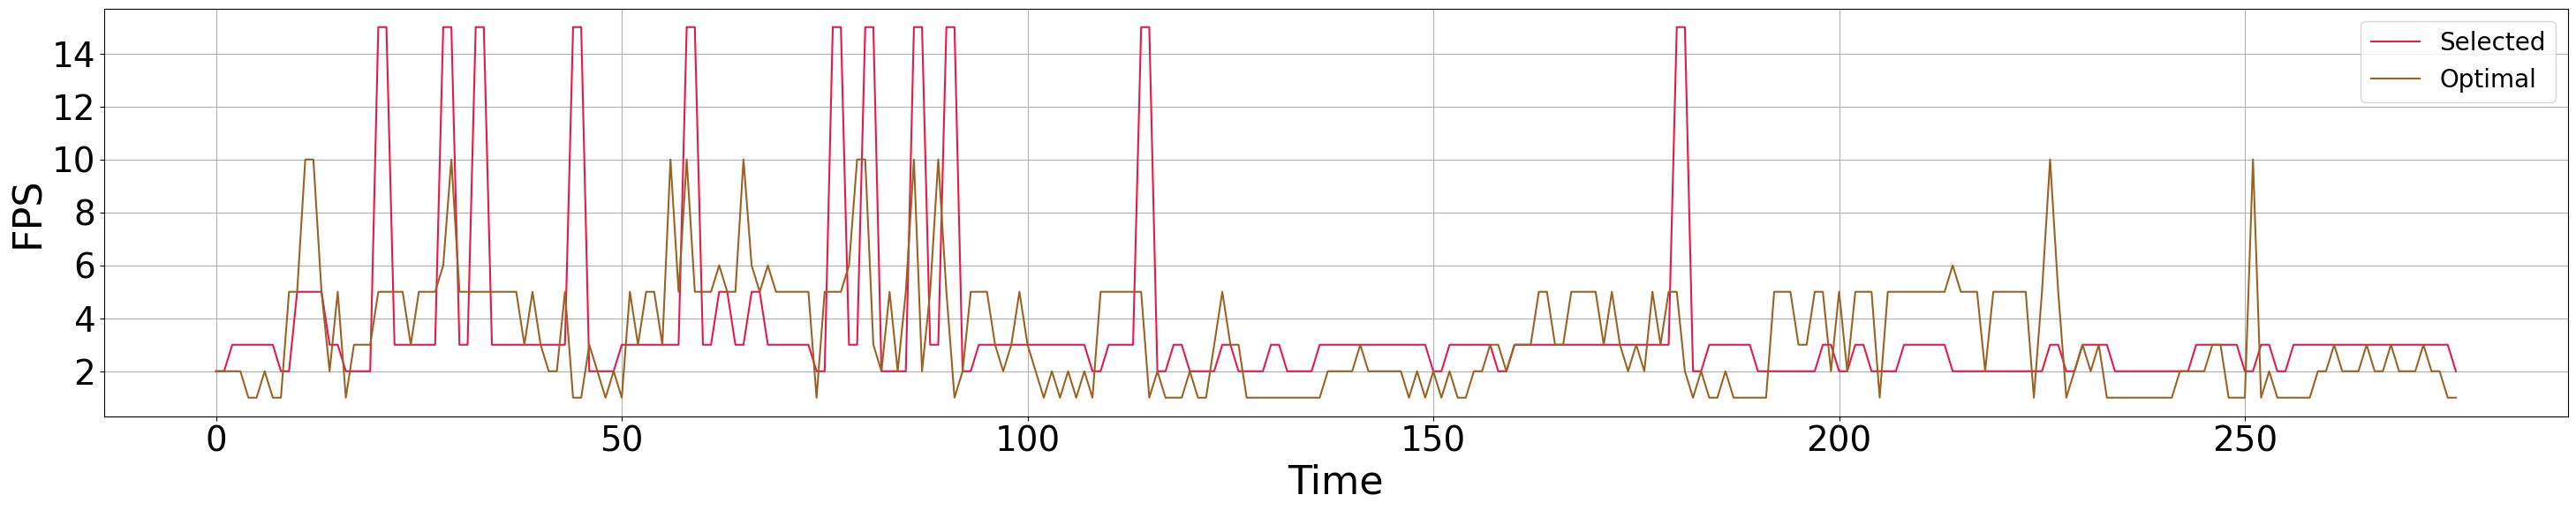

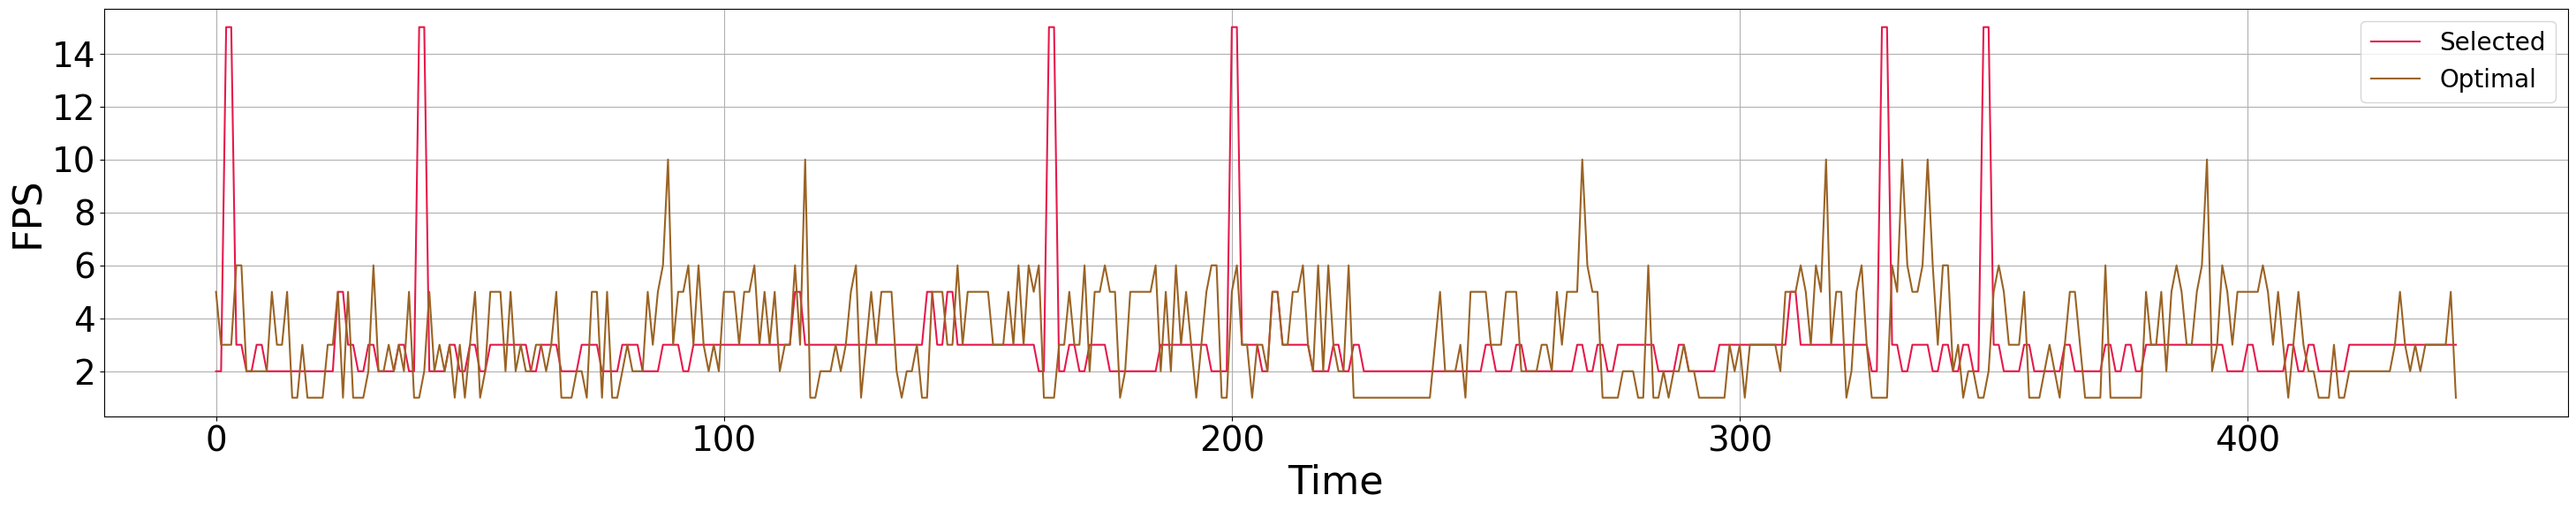

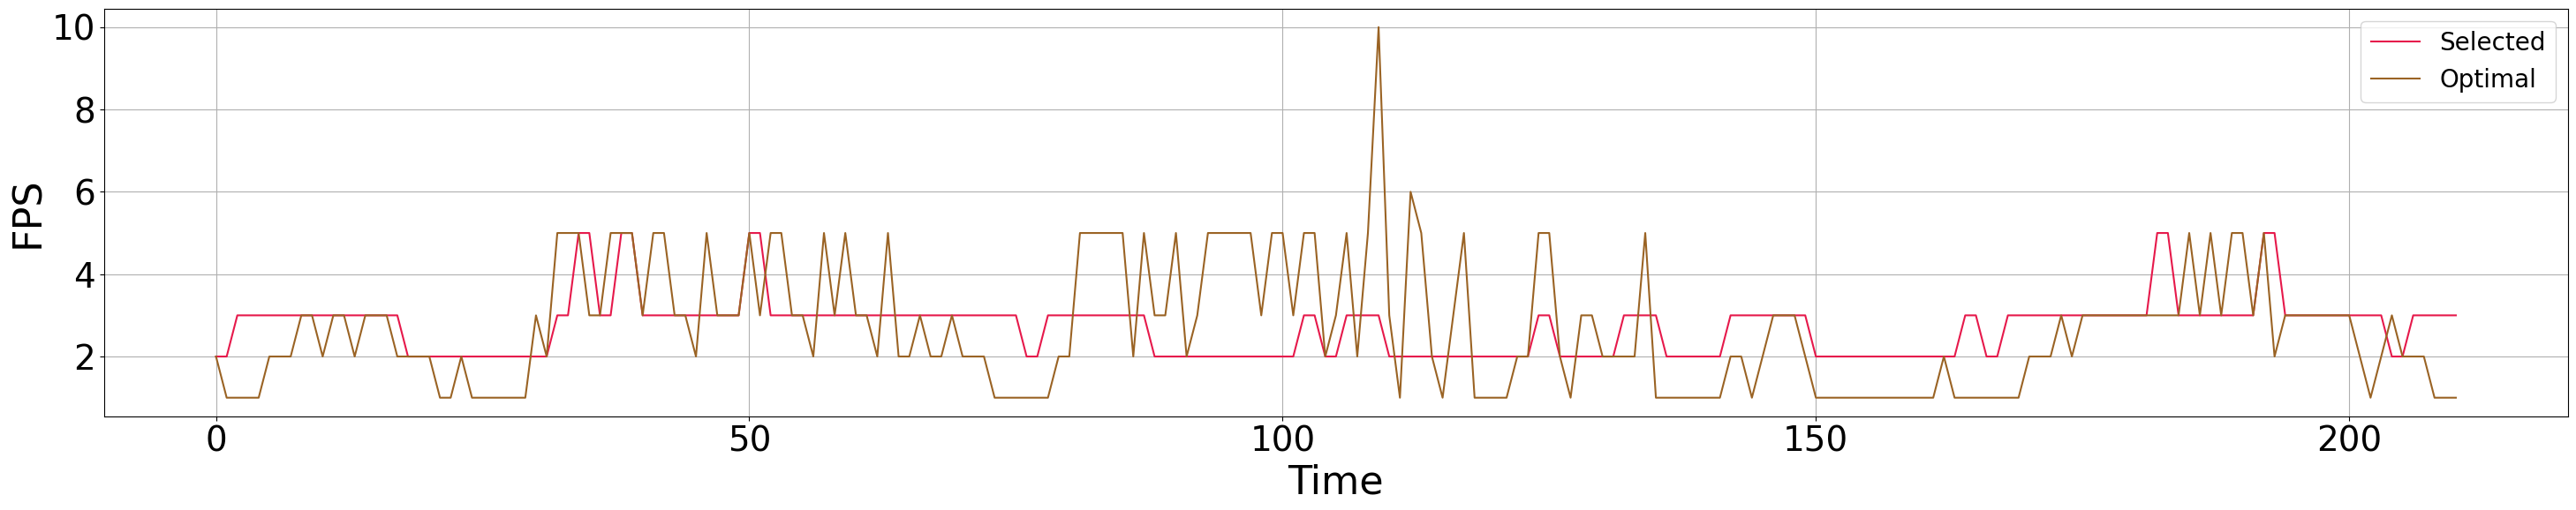

In [266]:
for l in range(len(plot_video_names)):
	if l in TEST_VIDEO_INDEXES:
		continue
	v = plot_video_names[l]
	
	selected_fps = all_selected_fps_list[v]
	min_fps = all_min_fps_list[v]
	time = range(0, len(selected_fps))

	plot_mutiple_lines(time, [selected_fps, min_fps], 'Time', 'FPS', ['Selected', 'Optimal'], '', (36, 6))

In [267]:
all_selected_accuracy_list = {}

for l in range(len(plot_video_names)):
		if l in TEST_VIDEO_INDEXES:
				continue
		v = plot_video_names[l]

		accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
		for class_idx in list(accuracy_result.keys()):
				selected_accuracy_list = []
				for i in range(len(accuracy_result[class_idx])):
						selected_throughput = str(all_selected_fps_list[v][i])
						selected_accuracy = accuracy_result[class_idx][i]['metric'][selected_throughput]['F1']
						selected_accuracy_list.append(selected_accuracy)

				all_selected_accuracy_list[v] = selected_accuracy_list

In [268]:
all_min_accuracy_list = {}

for l in range(len(plot_video_names)):
		if l in TEST_VIDEO_INDEXES:
				continue
		v = plot_video_names[l]

		accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
		for class_idx in list(accuracy_result.keys()):
				min_accuracy_list = []
				for i in range(len(accuracy_result[class_idx])):
						min_throughput = str(all_min_fps_list[v][i])
						min_accuracy = accuracy_result[class_idx][i]['metric'][min_throughput]['F1']
						min_accuracy_list.append(min_accuracy)

				all_min_accuracy_list[v] = min_accuracy_list

In [269]:
all_nearest_accuracy_list = {}

for l in range(len(plot_video_names)):
		if l in TEST_VIDEO_INDEXES:
				continue
		v = plot_video_names[l]

		accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
		for class_idx in list(accuracy_result.keys()):
				nearest_accuracy_list = []
				for i in range(len(accuracy_result[class_idx])):
						nearest_throughput = str(all_nearest_fps_list[v][i])
						nearest_accuracy = accuracy_result[class_idx][i]['metric'][nearest_throughput]['F1']
						nearest_accuracy_list.append(nearest_accuracy)

				all_nearest_accuracy_list[v] = nearest_accuracy_list

Average Selected F1 Accuracy: 0.7503248328261393
Average Nearest F1 Accuracy: 0.7287192174665107


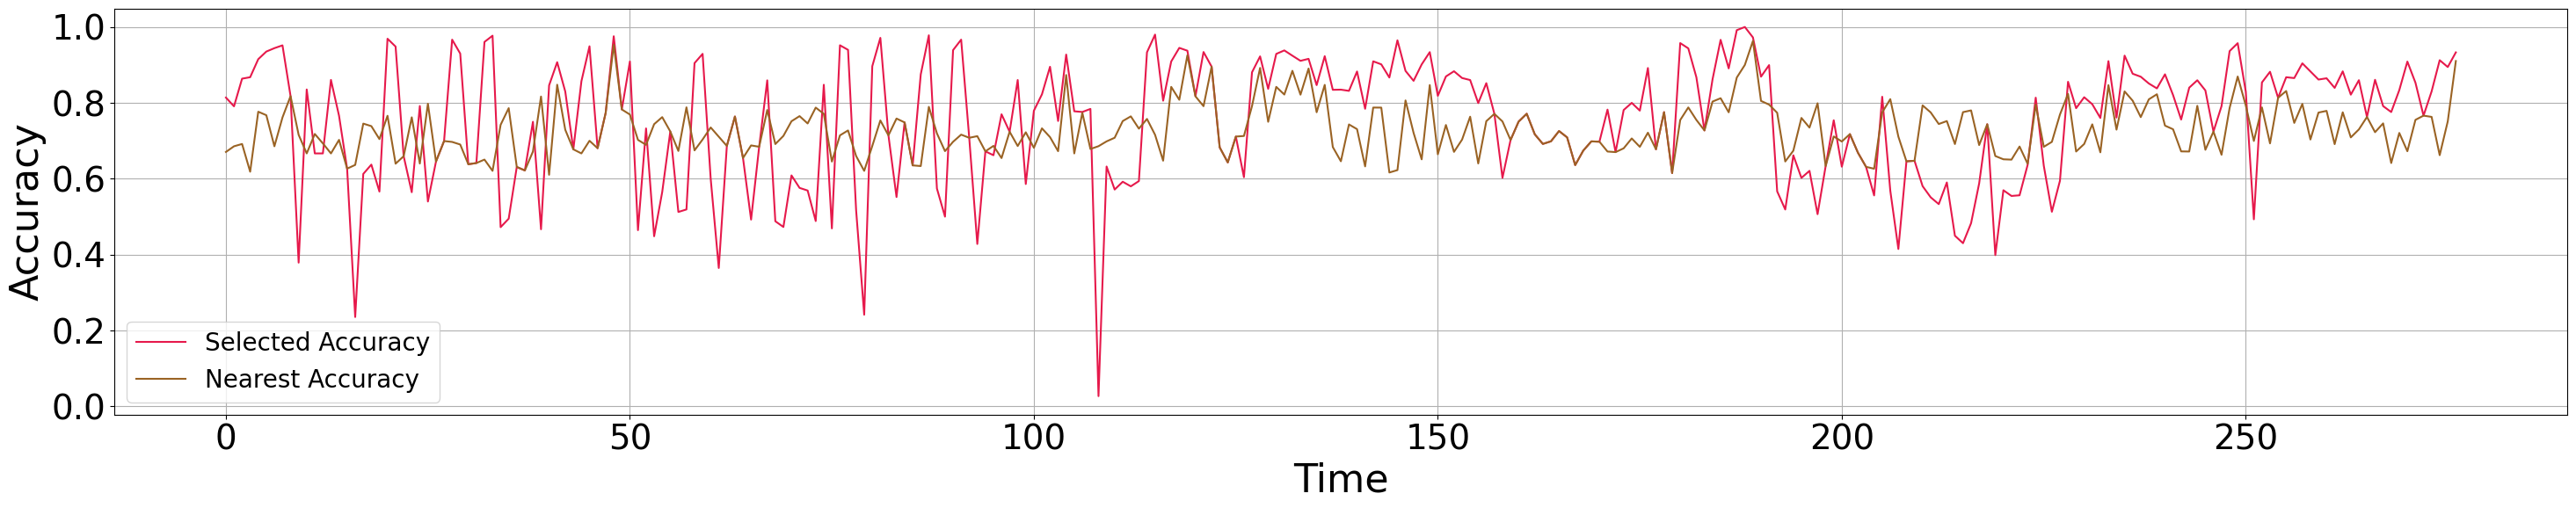

Average Selected F1 Accuracy: 0.7170267853126591
Average Nearest F1 Accuracy: 0.7270431543475725


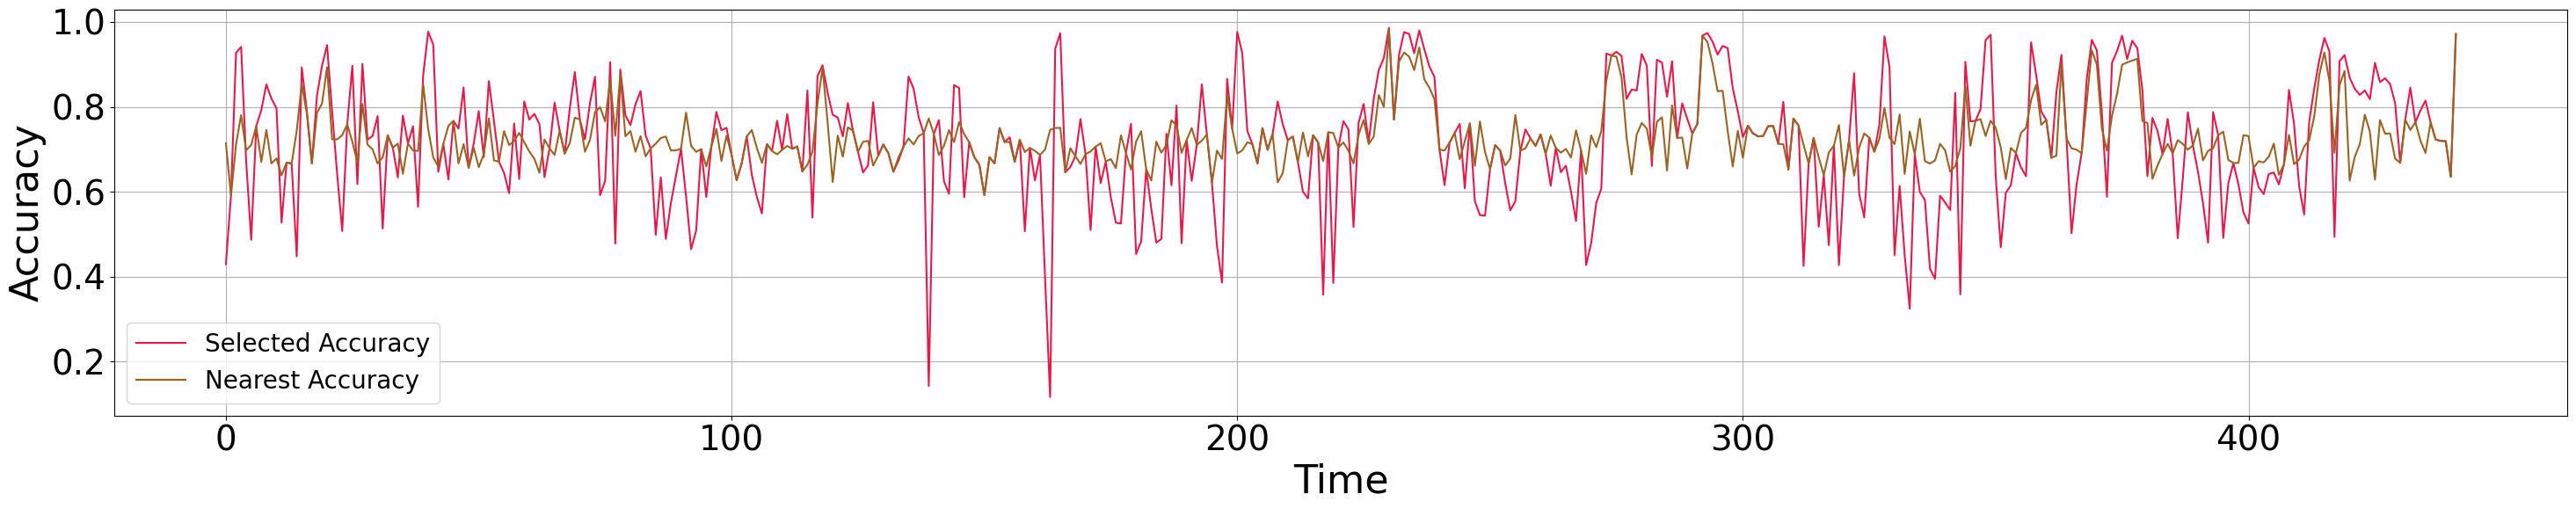

Average Selected F1 Accuracy: 0.776072799712394
Average Nearest F1 Accuracy: 0.7416944097020727


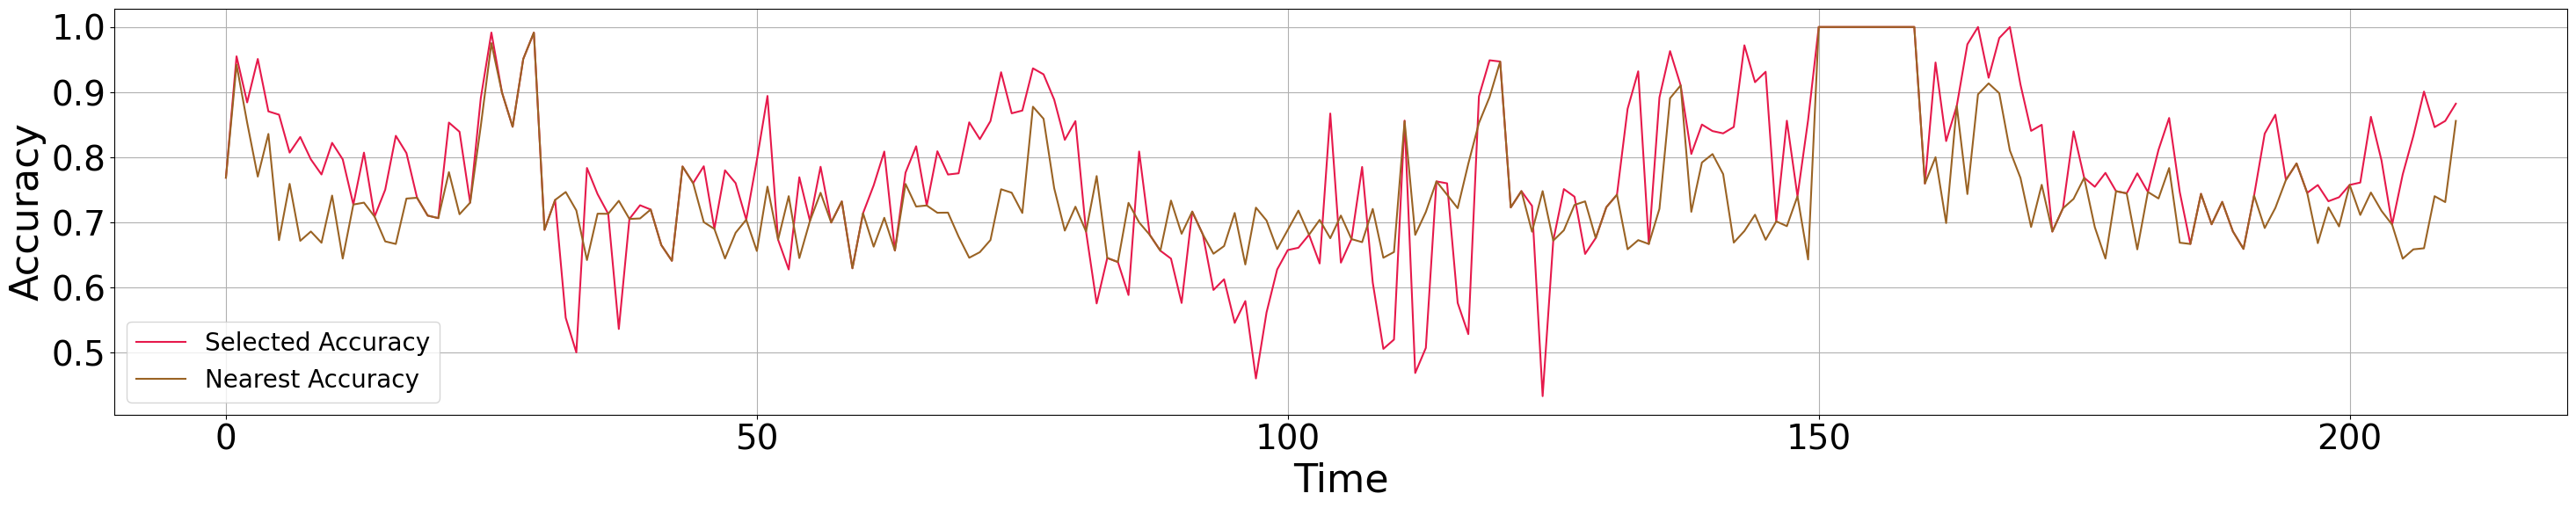

In [270]:
for l in range(len(plot_video_names)):
	if l in TEST_VIDEO_INDEXES:
		continue
	v = plot_video_names[l]

	selected_accuracy_list = all_selected_accuracy_list[v]
	nearest_accuracy_list = all_nearest_accuracy_list[v]
	time = range(0, len(selected_accuracy_list))

	print(f'Average Selected F1 Accuracy: {np.mean(np.array(selected_accuracy_list))}')
	print(f'Average Nearest F1 Accuracy: {np.mean(np.array(nearest_accuracy_list))}')
	plot_mutiple_lines(time, [selected_accuracy_list, nearest_accuracy_list], 'Time', 'Accuracy', ['Selected Accuracy', 'Nearest Accuracy'], '', (36, 6))

Average Selected Power: 3.813321014004453
Average Nearest Power: 3.66263701907515


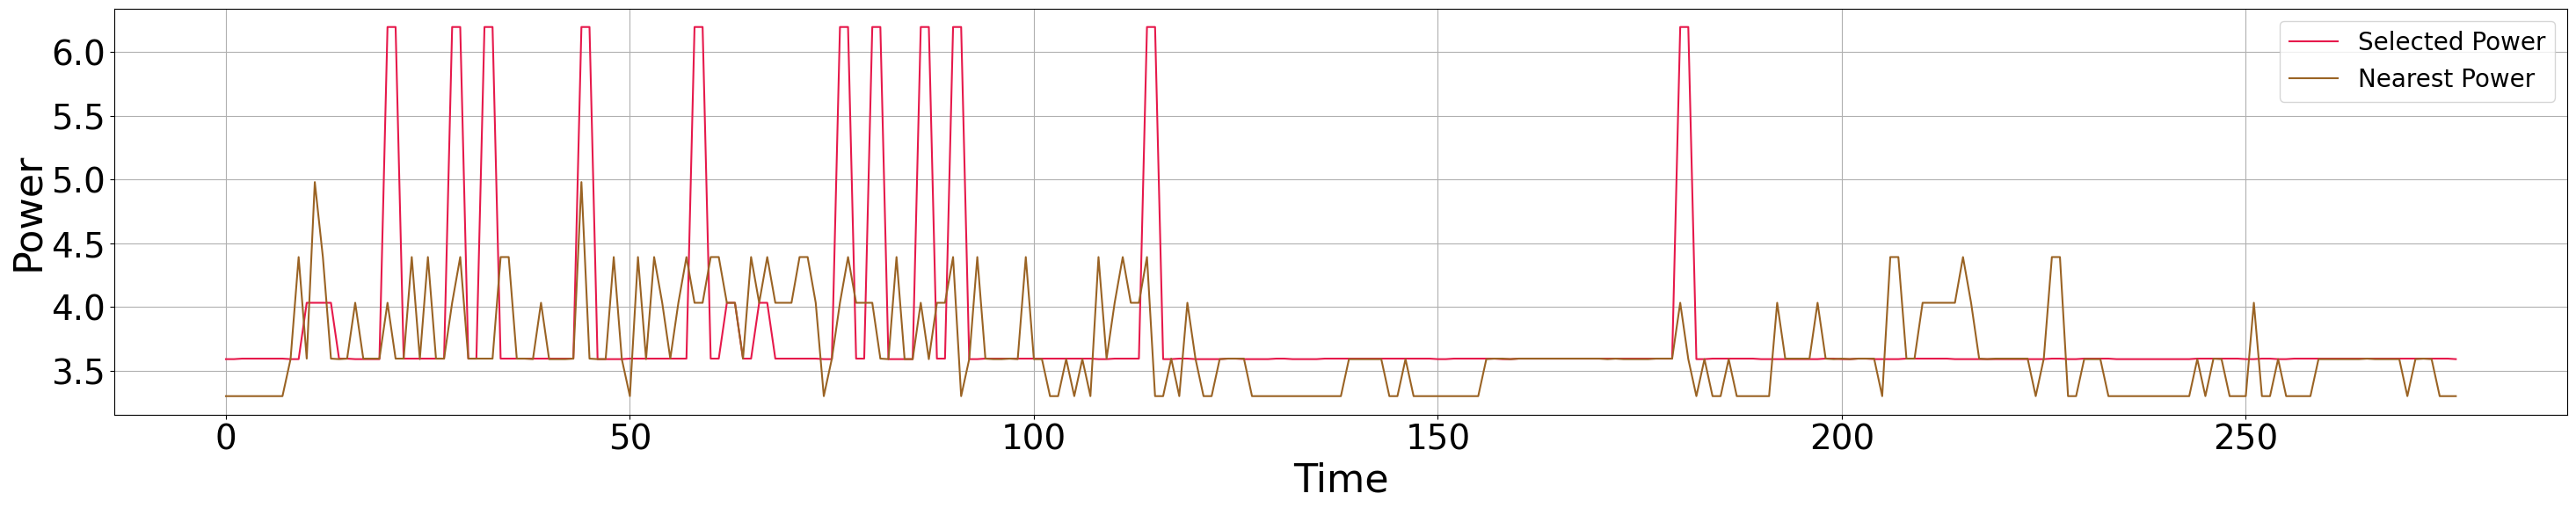

Average Selected Power: 3.6762331933859644
Average Nearest Power: 3.6522553422709416


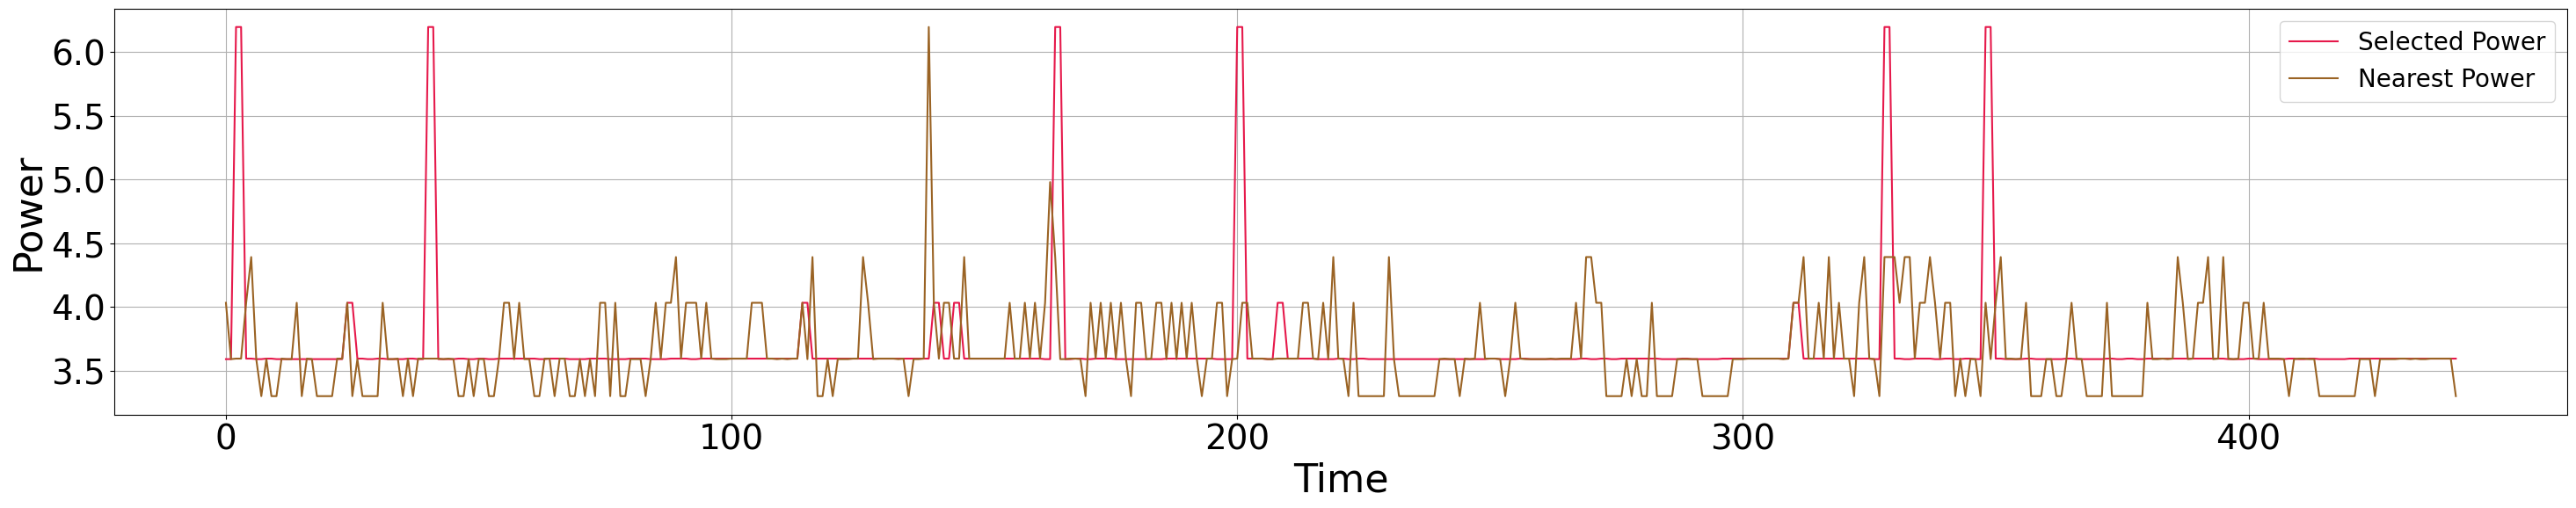

Average Selected Power: 3.614625517124379
Average Nearest Power: 3.541092242444336


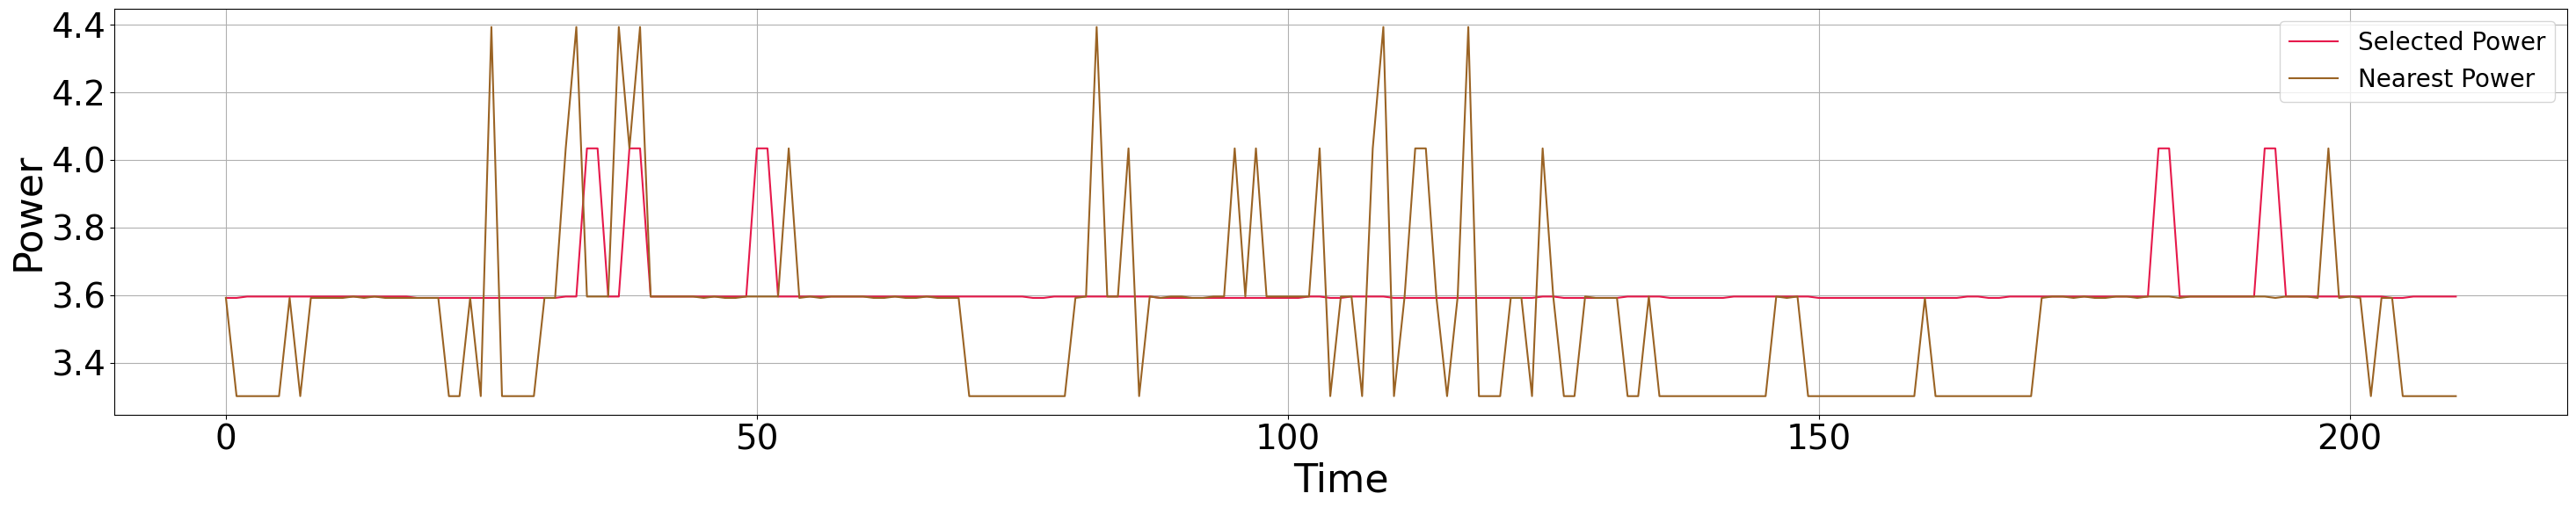

In [271]:
all_selected_power_list = {}
all_nearest_power_list = {}

power_profile = load_json_file(os.path.join(power_profile_directory))

for l in range(len(plot_video_names)):
	if l in TEST_VIDEO_INDEXES:
		continue
	v = plot_video_names[l]

	max_power = power_profile[str(max([int(k) for k in list(power_profile.keys())]))]
	
	selected_power = []
	selected_throughput = all_selected_fps_list[v]

	for st in selected_throughput:
		if str(st) in power_profile:
			selected_power.append(power_profile[str(st)])
		else:
			selected_power.append(max_power)
	
	all_selected_power_list[v] = selected_power
	
	nearest_power = []
	nearest_throughput = all_nearest_fps_list[v]
	
	for mt in nearest_throughput:
		if str(mt) in power_profile:
			nearest_power.append(power_profile[str(mt)])
		else:
			nearest_power.append(max_power)
	
	all_nearest_power_list[v] = nearest_power
	
	# performant_power = [max_power] * len(selected_power)

	time = range(0, len(selected_throughput))
	print(f'Average Selected Power: {np.mean(np.array(selected_power))}')
	print(f'Average Nearest Power: {np.mean(np.array(nearest_power))}')
	plot_mutiple_lines(time, [selected_power, nearest_power], 'Time', 'Power', ['Selected Power', 'Nearest Power'], '', (36, 6))

In [272]:
def plot_two_scatter(x1, y1, x2, y2, title_1, x1_axis, y1_axis, title_2, x2_axis, y2_axis):
	# Create figure and axes
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns for horizontal layout

	# Plot the first scatter plot
	ax1.scatter(x1, y1)
	ax1.set_title(title_1)
	ax1.set_xlabel(x1_axis)
	ax1.set_ylabel(y1_axis)

	# Plot the second scatter plot
	ax2.scatter(x2, y2)
	ax2.set_title(title_2)
	ax2.set_xlabel(x2_axis)
	ax2.set_ylabel(y2_axis)

	# Show the plots
	plt.tight_layout()
	plt.show()

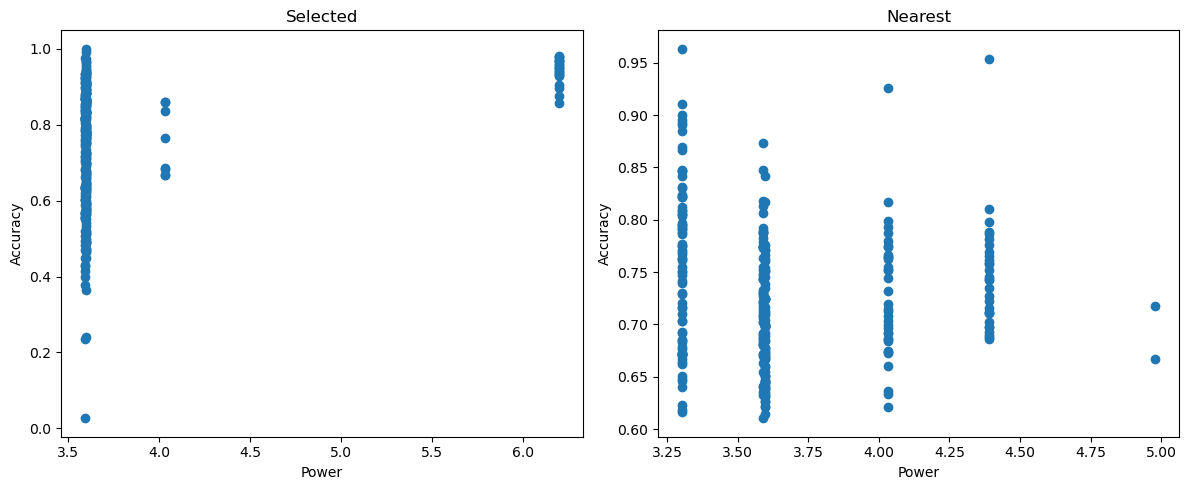

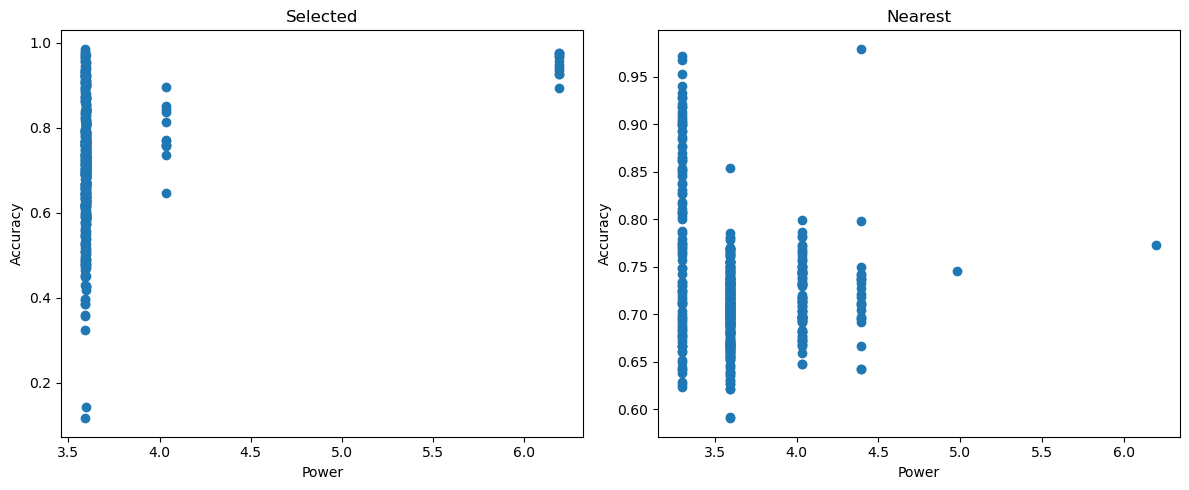

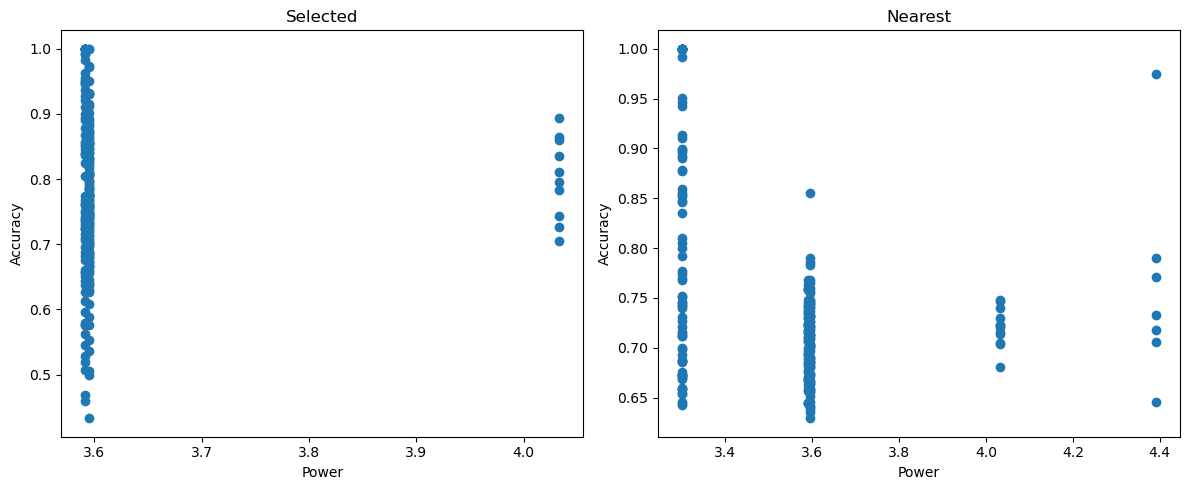

In [273]:
for l in range(len(plot_video_names)):
	if l in TEST_VIDEO_INDEXES:
		continue
	v = plot_video_names[l]

	selected_power = all_selected_power_list[v]
	nearest_power = all_nearest_power_list[v]

	selected_accuracy = all_selected_accuracy_list[v]
	nearest_accuracy = all_nearest_accuracy_list[v]

	plot_two_scatter(selected_power, selected_accuracy, nearest_power, nearest_accuracy, "Selected", "Power", "Accuracy", "Nearest", "Power", "Accuracy")